In [1]:
from datetime import date
import pandas as pd
import os
import glob
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib_venn import venn2 

In [2]:
# load custom collection of functions
import sys
sys.path.append('/home/schmiedc/FMP_Docs/Projects/2024-11-25_Bioactives_Revision/EU-OS_bioactives/')
import utility_functions as UTIL

In [3]:
parent_directory = "/home/schmiedc/FMP_Docs/Projects/2024-11-25_Bioactives_Revision/"

input_path = parent_directory + "results/"

annot_path = parent_directory  + "annotations/"

output_path = parent_directory + "revision_results/"

figure_path = parent_directory + "revision_figures/"

In [4]:
file_USC_HepG2_type = '/*[0-9]_' + 'USC_HepG2_norm.csv'
files_USC_HepG2 = glob.glob(input_path + file_USC_HepG2_type)

### gets latest file
max_file_USC_HepG2 = max(files_USC_HepG2, key=os.path.getctime)

### load file
data_USC_HepG2_Norm = pd.read_csv(max_file_USC_HepG2)
data_USC_HepG2_Norm.shape

(10747, 2984)

In [5]:
file_USC_HepG2_norm_median_type = '/*[0-9]_' + 'USC_HepG2_norm_median_full.csv'
files_USC_HepG2_norm_median = glob.glob(input_path + file_USC_HepG2_norm_median_type)

### gets latest file
max_file_USC_HepG2_norm_median = max(files_USC_HepG2_norm_median, key=os.path.getctime)

### load file
data_USC_HepG2_Norm_median = pd.read_csv(max_file_USC_HepG2_norm_median)
data_USC_HepG2_Norm_median.shape

(2499, 2982)

# Missing compounds

In [6]:
file_type = '/*[0-9]_' + 'Annotation_Bioactives_U2OS_Corrected.csv'
files = glob.glob(annot_path + file_type)

### gets latest file
max_file = max(files, key=os.path.getctime)

### load file
Annotation_Bioactives = pd.read_csv(max_file)
Annotation_Bioactives.shape

(10752, 6)

In [7]:
all_ID = Annotation_Bioactives["Metadata_EOS"].unique()
len(all_ID)

2467

In [8]:
USC_HepG2_ID = data_USC_HepG2_Norm_median["Metadata_EOS"].unique()
print("HepG2: There are ",len(all_ID) - len(USC_HepG2_ID),"compounds missing")

HepG2: There are  0 compounds missing


In [9]:
USC_HepG2_ID_frame = pd.DataFrame(USC_HepG2_ID, columns=["ID"])
all_ID_frame = pd.DataFrame(all_ID, columns=["ID"])

In [10]:
USC_HepG2_missing_compounds = pd.merge(all_ID_frame, 
                                 USC_HepG2_ID_frame,
                                 on = ["ID"],
                                 how = "left",
                                 indicator = True)

USC_HepG2_missing_compounds = USC_HepG2_missing_compounds[USC_HepG2_missing_compounds["_merge"] == 'left_only'].dropna(axis='columns')

In [11]:
### 
filename = output_path + str(date.today()) + "_USC_HepG2_raw_missing_compounds.csv"
USC_HepG2_missing_compounds.to_csv(filename, index = False)

# Compounds with less than 4 replicates

In [12]:
data_USC_HepG2_Norm_replicates = data_USC_HepG2_Norm['Metadata_EOS'].value_counts()
print("USC_HepG2: There are",len(data_USC_HepG2_Norm_replicates[data_USC_HepG2_Norm_replicates.iloc[:] < 4]), "compounds with less than 4 replicates.")

USC_HepG2: There are 4 compounds with less than 4 replicates.


<AxesSubplot: xlabel='Metadata_EOS', ylabel='Count'>

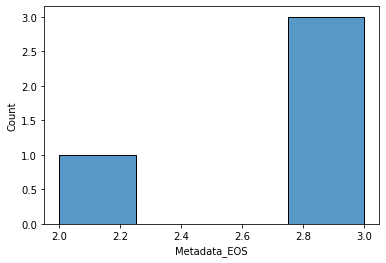

In [13]:
data_USC_HepG2_Norm_replicates_less = data_USC_HepG2_Norm_replicates[data_USC_HepG2_Norm_replicates.loc[:] < 4]
data_USC_HepG2_Norm_replicates_less = data_USC_HepG2_Norm_replicates_less.to_frame()
sns.histplot(data=data_USC_HepG2_Norm_replicates_less, x="Metadata_EOS")

# Cell number

In [14]:
data_USC_HepG2_Norm_mod = data_USC_HepG2_Norm.columns.drop(list(data_USC_HepG2_Norm.filter(regex="Metadata_")) )

In [15]:
data_USC_HepG2_Norm_mod = data_USC_HepG2_Norm[
    data_USC_HepG2_Norm.columns[
        data_USC_HepG2_Norm.columns.isin(
            ["Metadata_EOS", "Metadata_Well", "Metadata_Batch", "Metadata_Plate", "Metadata_Object_Count"])]]

In [16]:
print("Median USC_HepG2 cell number:",data_USC_HepG2_Norm["Metadata_Object_Count"].median(),"cells")

Median USC_HepG2 cell number: 1455.0 cells


In [17]:
# plot cell numbers of controls
USC_HepG2_Norm_Controls = data_USC_HepG2_Norm[(data_USC_HepG2_Norm["Metadata_EOS"] == "DMSO") |
                                    (data_USC_HepG2_Norm["Metadata_EOS"] == "Nocodazole") |
                                    (data_USC_HepG2_Norm["Metadata_EOS"] == "Tetrandrine") ]

In [18]:
print("Median HepG2 DMSO cell number:",USC_HepG2_Norm_Controls[(USC_HepG2_Norm_Controls["Metadata_EOS"] == "DMSO")]["Metadata_Object_Count"].median(),"cells")
print("Median HepG2 Nocodazole cell number:",USC_HepG2_Norm_Controls[(USC_HepG2_Norm_Controls["Metadata_EOS"] == "Nocodazole")]["Metadata_Object_Count"].median(),"cells")
print("Median HepG2 Tetrandrine cell number:",USC_HepG2_Norm_Controls[(USC_HepG2_Norm_Controls["Metadata_EOS"] == "Tetrandrine")]["Metadata_Object_Count"].median(),"cells")

Median HepG2 DMSO cell number: 1240.0 cells
Median HepG2 Nocodazole cell number: 739.5 cells
Median HepG2 Tetrandrine cell number: 1075.0 cells


# Compute toxicity

In [19]:
## 2.5 Std from population median
SD_Threshold = 2.5

USC_HepG2_tox_threshold_1 = data_USC_HepG2_Norm_median["Metadata_Object_Count"].median() - (SD_Threshold *  data_USC_HepG2_Norm_median["Metadata_Object_Count"].std())
print("USC_HepG2 tox_threshold_1:", USC_HepG2_tox_threshold_1)

USC_HepG2 tox_threshold_1: 475.81500489682094


In [20]:
USC_HepG2_Toxic_conditions_1 = data_USC_HepG2_Norm_median.loc[data_USC_HepG2_Norm_median["Metadata_Object_Count"] < USC_HepG2_tox_threshold_1]
print("HepG2 toxic conditions:",len(USC_HepG2_Toxic_conditions_1),"compounds (2.5 Std from population median)")

HepG2 toxic conditions: 91 compounds (2.5 Std from population median)


# Missing and toxic compounds

In [21]:
USC_HepG2_missing_compounds_clean = USC_HepG2_missing_compounds.drop(["_merge"], axis=1)
USC_HepG2_missing_compounds_clean = USC_HepG2_missing_compounds_clean.rename(columns={"ID" : "Metadata_EOS"})

USC_HepG2_Toxic_conditions_1_clean = USC_HepG2_Toxic_conditions_1[["Metadata_EOS"]]

USC_HepG2_toxic_all = pd.concat([USC_HepG2_missing_compounds_clean, 
                            USC_HepG2_Toxic_conditions_1_clean], ignore_index=True)

In [22]:
### 
filename = output_path + str(date.today()) + "_USC_HepG2_toxic_all.csv"
USC_HepG2_toxic_all.to_csv(filename, index = False)

In [23]:
len(USC_HepG2_toxic_all["Metadata_EOS"].unique())

91